In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import imageio
from datetime import datetime, timedelta
import geopandas as gpd
from shapely.geometry import Point

# Assuming your data is in a CSV file with columns: 'IncidentDate', 'Latitude', 'Longitude'
data = pd.read_csv('../data/cleaned_2021-jan2025.csv')
data.dropna(subset=['Latitude', 'Longitude'])
data['IncidentDate'] = pd.to_datetime(data['IncidentDate'], format="mixed", dayfirst=False)

len(data)

data = data[(data['IncidentDate'] >= '2024-01-01') & (data['IncidentDate'] < '2025-01-01')]


C:\Users\jz043x\AppData\Local\Temp\ipykernel_11744\3973802826.py:10: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../data/cleaned_2021-jan2025.csv')


In [2]:
# Load the neighborhood shapefile
city_bounds = gpd.read_file('../data/city_bounds/stl_boundary.shp')


points = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data.Longitude, data.Latitude))


# points = points.to_crs(city_bounds.crs)
points.set_crs(epsg=4326, inplace=True)

if city_bounds.crs != points.crs:
    points = points.to_crs(city_bounds.crs)

within_points = gpd.sjoin(points, city_bounds, how='inner', predicate = 'within')

columns_to_drop = ['index_right'] + list(city_bounds.columns)

within_points = within_points.drop(columns=columns_to_drop)

print(len(within_points))
data = within_points

48915


In [3]:
# Define the grid size (e.g., 0.01 degrees for a medium-sized city)
lat_min, lat_max = data['Latitude'].min(), data['Latitude'].max()
lon_min, lon_max = data['Longitude'].min(), data['Longitude'].max()
lat_bins = np.arange(lat_min, lat_max, 0.003)
lon_bins = np.arange(lon_min, lon_max, 0.003)

print(lat_min, lat_max, len(lat_bins))
print(lon_min, lon_max, len(lon_bins))

38.537907 38.771904 78
-90.318869 -90.178843 47


In [4]:
# create heatmap
heatmap, _, _ = np.histogram2d(data['Latitude'], data['Longitude'], bins=[lat_bins, lon_bins])

In [22]:
import esda
import libpysal

# Assuming heatmap, lat_bins, and lon_bins are already defined
# heatmap, _, _ = np.histogram2d(data['Latitude'], data['Longitude'], bins=[lat_bins, lon_bins])
def calc_moran(heatmap):
    # Flatten the data array to a 1D array
    data_flat = heatmap.flatten()
    
    # Create a spatial weights matrix
    # For example, using a distance-based weights matrix with a threshold
    coords = [(i, j) for i in range(heatmap.shape[0]) for j in range(heatmap.shape[1])]
    w = libpysal.weights.DistanceBand.from_array(coords, threshold=1.5)  # Adjust threshold as needed
    
    # Calculate Moran's I
    moran = esda.Moran(data_flat, w)
    
    # Output Moran's I value
    print(f"Total 2024 Heatmap Moran's I: {moran.I}")
    print(f"p-value: {moran.p_sim}")
    print(f"Expected I: {moran.EI}")

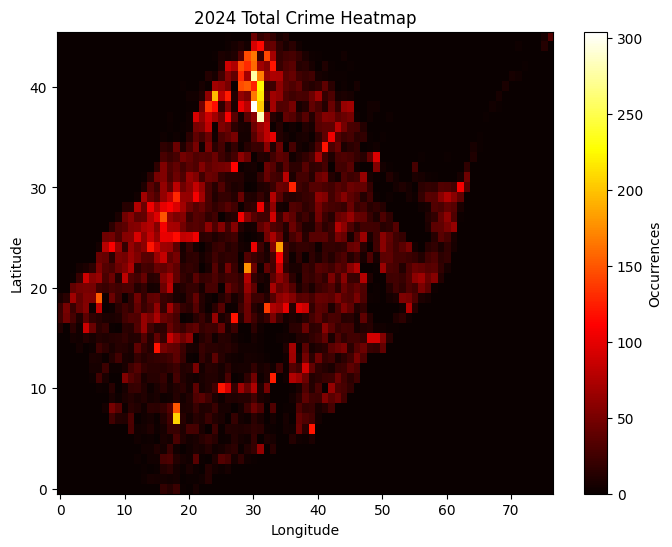

In [6]:

def plot_heatmap(heatmap, title):
    plt.figure(figsize=(8, 6))
    plt.imshow(heatmap.T, origin='lower', aspect='auto', cmap='hot', interpolation='nearest')
    plt.colorbar(label='Occurrences')
    plt.title(title)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

plot_heatmap(heatmap, '2024 Total Crime Heatmap')
# calc_moran(heatmap)

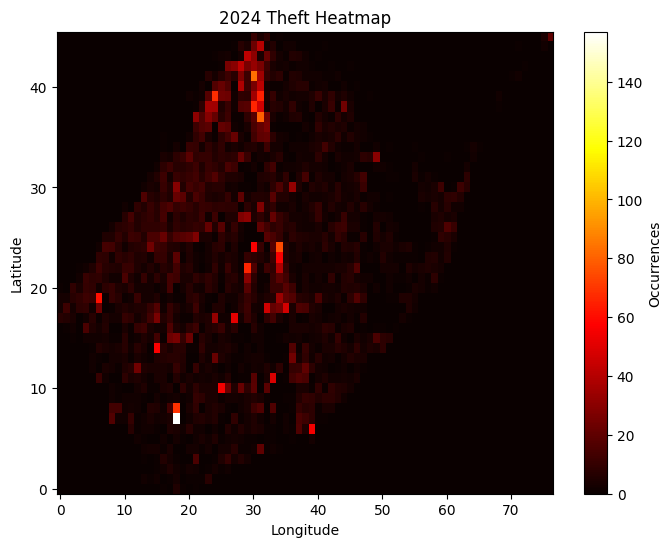

In [7]:
# create heatmap for 
theft_heatmap, _, _ = np.histogram2d(data[data['NIBRS'].str.startswith('23')]['Latitude'], data[data['NIBRS'].str.startswith('23')]['Longitude'], bins=[lat_bins, lon_bins])


plot_heatmap(theft_heatmap, '2024 Theft Heatmap')
# calc_moran(theft_heatmap)

In [9]:
np.set_printoptions(threshold=np.inf)
print(heatmap)

[[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.  10.  23.  22.   8.   1.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   1.  46.  49.  15.   0.   1.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   5.  15.  28.  22.  68.  40.   2.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    5.   4.   4.  10.  42.  41.  48.  21.   5.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   

In [13]:
heatmap.shape

(77, 46)

In [12]:
np.mean(theft_heatmap)

2.8769057029926595

In [23]:
calc_moran(heatmap)

Total 2024 Heatmap Moran's I: 0.5869069954641607
p-value: 0.001
Expected I: -0.0002824060999717594


In [24]:
calc_moran(theft_heatmap)

Total 2024 Heatmap Moran's I: 0.38613230096502094
p-value: 0.001
Expected I: -0.0002824060999717594


In [32]:
one_week_data = data[(data['IncidentDate'] >= '2024-01-01') & (data['IncidentDate'] < '2024-01-08')]
one_month_data = data[(data['IncidentDate'] >= '2024-01-01') & (data['IncidentDate'] < '2024-02-01')]

one_week_heatmap, _, _ = np.histogram2d(one_week_data['Latitude'], one_week_data['Longitude'], bins=[lat_bins, lon_bins])
one_month_heatmap, _, _ = np.histogram2d(one_month_data['Latitude'], one_month_data['Longitude'], bins=[lat_bins, lon_bins])

one_week_theft, _, _ = np.histogram2d(one_week_data[one_week_data['NIBRS'].str.startswith('23')]['Latitude'], one_week_data[one_week_data['NIBRS'].str.startswith('23')]['Longitude'], bins=[lat_bins, lon_bins])
one_month_theft, _, _ = np.histogram2d(one_month_data[one_month_data['NIBRS'].str.startswith('23')]['Latitude'], one_month_data[one_month_data['NIBRS'].str.startswith('23')]['Longitude'], bins=[lat_bins, lon_bins])


In [29]:
calc_moran(one_week_heatmap)

Total 2024 Heatmap Moran's I: 0.20376180369180172
p-value: 0.001
Expected I: -0.0002824060999717594


In [30]:
calc_moran(one_month_heatmap)

Total 2024 Heatmap Moran's I: 0.3876190094799871
p-value: 0.001
Expected I: -0.0002824060999717594


In [33]:
calc_moran(one_week_theft)

Total 2024 Heatmap Moran's I: 0.10279854694223038
p-value: 0.001
Expected I: -0.0002824060999717594


In [34]:
calc_moran(one_month_theft)

Total 2024 Heatmap Moran's I: 0.227424200834795
p-value: 0.001
Expected I: -0.0002824060999717594


In [ ]:
# mantel test
geographicdata.science local autocorrelation